# 01 — Exploración de Datos

Analiza los datos de irradiancia solar descargados con PVWatts API (NREL) para 13 ciudades chilenas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(exist_ok=True)

## 1. Cargar baseline PVWatts

In [2]:
df = pd.read_csv(DATA_RAW / 'pvwatts_chile_baseline.csv')
print(df.shape)
df

(6, 6)


,city,region,latitude,longitude,solrad_annual,ac_annual_ref
0,Antofagasta,Antofagasta,-23.65,-70.40,6.260674,9008.872566
1,Santiago,Metropolitana,-33.45,-70.67,5.276957,7312.579917
2,Rancagua,O'Higgins,-34.17,-70.74,5.265410,7297.030997
3,Concepción,Biobío,-36.82,-73.05,4.834485,6978.581826
4,Temuco,La Araucanía,-38.74,-72.60,4.805798,6937.866684
5,Punta Arenas,Magallanes,-53.16,-70.91,3.930570,5950.260958


In [3]:
df.describe().round(2)

,latitude,longitude,solrad_annual,ac_annual_ref
count,6.00,6.00,6.00,6.00
mean,-36.66,-71.40,5.06,7247.53
std,9.62,1.13,0.76,996.01
min,-53.16,-73.05,3.93,5950.26
25%,-38.26,-72.18,4.81,6948.05
50%,-35.50,-70.82,5.05,7137.81
75%,-33.63,-70.69,5.27,7308.69
max,-23.65,-70.40,6.26,9008.87


In [4]:
df.isnull().sum()

city             0
region           0
latitude         0
longitude        0
solrad_annual    0
ac_annual_ref    0
dtype: int64

## 2. Irradiancia y producción por ciudad (norte → sur)

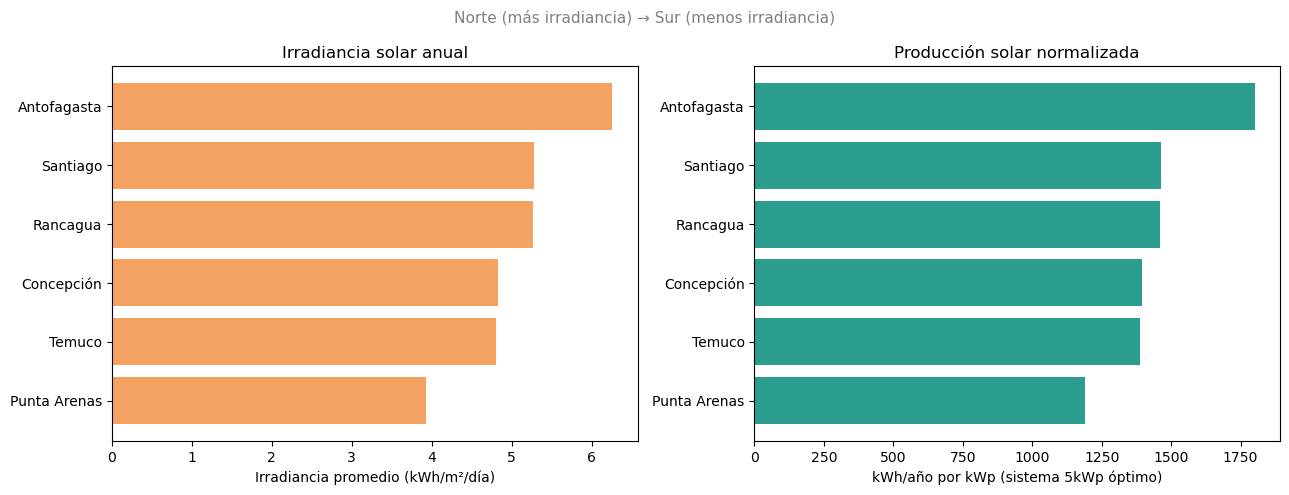

In [5]:
df_sorted = df.sort_values('latitude', ascending=False)  # norte primero

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(df_sorted['city'], df_sorted['solrad_annual'], color='#f4a261')
axes[0].set_xlabel('Irradiancia promedio (kWh/m²/día)')
axes[0].set_title('Irradiancia solar anual')
axes[0].invert_yaxis()

# Producción normalizada por kWp (sistema de 5kWp en condiciones óptimas)
df_sorted['kwh_per_kwp'] = df_sorted['ac_annual_ref'] / 5
axes[1].barh(df_sorted['city'], df_sorted['kwh_per_kwp'], color='#2a9d8f')
axes[1].set_xlabel('kWh/año por kWp (sistema 5kWp óptimo)')
axes[1].set_title('Producción solar normalizada')
axes[1].invert_yaxis()

plt.suptitle('Norte (más irradiancia) → Sur (menos irradiancia)', fontsize=11, color='gray')
plt.tight_layout()

## 3. Correlación: latitud vs irradiancia

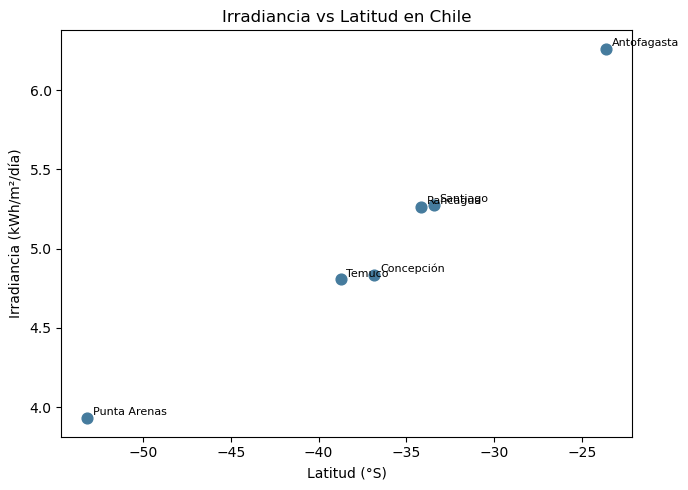

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['latitude'], df['solrad_annual'], s=60, color='#457b9d')
for _, row in df.iterrows():
    ax.annotate(row['city'], (row['latitude'], row['solrad_annual']),
                fontsize=8, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Latitud (°S)')
ax.set_ylabel('Irradiancia (kWh/m²/día)')
ax.set_title('Irradiancia vs Latitud en Chile')
plt.tight_layout()

## 4. Mapa de calor de correlaciones

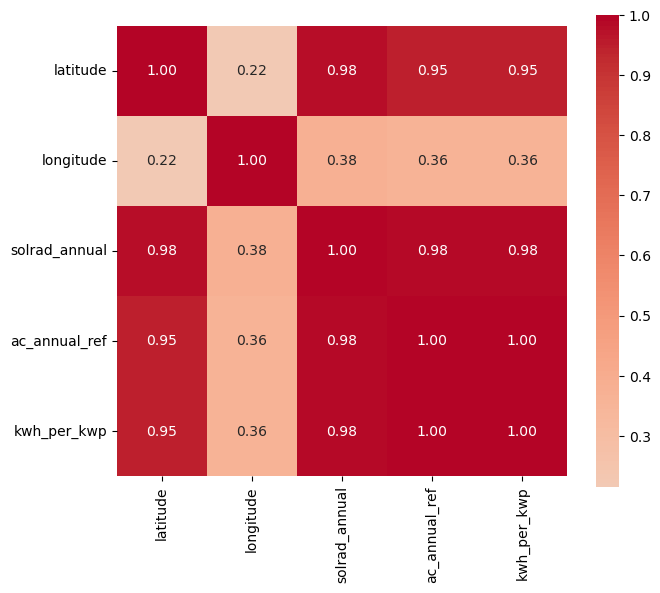

In [7]:
df['kwh_per_kwp'] = df['ac_annual_ref'] / 5
numeric_cols = ['latitude', 'longitude', 'solrad_annual', 'ac_annual_ref', 'kwh_per_kwp']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, ax=ax
)
plt.tight_layout()

## 5. Exportar datos limpios

In [8]:
df.to_csv(DATA_PROC / 'pvwatts_chile_clean.csv', index=False)
print(f'Guardado: {df.shape}')

Guardado: (6, 7)
